In [63]:
from __future__ import annotations

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [64]:
def build_env(slippery):
    env = gym.make("FrozenLake-v1",is_slippery=slippery,render_mode = "rgb_array",map_name = "8x8")
    env.reset()
    return env

In [65]:
def shape_rewards(env):
    desc = env.unwrapped.desc.flatten()
    P = env.unwrapped.P
    for state in P:
        for action in P[state]:           
            new_transitions = []
            for prob, next_state, old_reward, terminated in P[state][action]:
                tile_type = desc[next_state]
                if tile_type == b'H':
                    custom_reward = 0   
                elif tile_type == b'G':
                    custom_reward = 1.0    
                elif tile_type == b'S':
                    custom_reward = 0 
                else: 
                    custom_reward = 0
                new_transitions.append((prob, next_state, custom_reward, terminated))
            P[state][action] = new_transitions
    return env

In [66]:
def policy_iteration(env:gym.Env,model,gamma,theta,n_itr=100):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    policy = np.random.randint(0,n_actions,size=n_states)
    values = np.zeros(n_states)
    qvalues = np.zeros((n_states,n_actions))
    desc = env.unwrapped.desc.flatten() 
    terminal_states = [s for s, tile in enumerate(desc) if tile in [b'H', b'G']]
    for temp in range(n_itr):
        delta = 10000000
        while delta>=theta:
            delta = 0
            for state in range(n_states):
                if state in terminal_states:
                    continue
                v = values[state]
                values[state]=0
                for prob,next_state,r,terminated in model[state][policy[state]]:
                    values[state]+=prob*(r+gamma*values[next_state])
                delta = max(delta,abs(v-values[state]))
        for state in range(n_states):
            if state in terminal_states:
                continue
            for action,transitions in model[state].items():
                qvalues[state][action]=0
                for prob,next_state,r,terminated in transitions:
                    qvalues[state][action]+=prob*(r+gamma*values[next_state])
            policy[state] = np.argmax(qvalues[state])
    return policy
    

In [67]:
def value_iteration(env:gym.Env,model,gamma,theta):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    policy = np.random.randint(0,n_actions,size=n_states)
    values = np.zeros(n_states)
    qvalues = np.zeros((n_states,n_actions))
    desc = env.unwrapped.desc.flatten() 
    terminal_states = [s for s, tile in enumerate(desc) if tile in [b'H', b'G']]
    delta = 1000000000
    while delta>theta:
        delta = 0
        for state in range(n_states):
            if state in terminal_states:
                continue
            v = values[state]
            values[state] = 0
            for action,transitions in model[state].items():
                val = 0
                for prob,next_state,r,terminated in transitions:
                    val += prob*(r+gamma*values[next_state])
                values[state] = max(values[state],val)
            delta = max(delta,abs(v-values[state]))
    for state in range(n_states):
        if state in terminal_states:
            continue
        for action,transitions in model[state].items():
            qvalues[state][action]=0
            for prob,next_state,r,terminated in transitions:
                qvalues[state][action]+=prob*(r+gamma*values[next_state])
        policy[state] = np.argmax(qvalues[state])  
    return policy
    

In [68]:
def matrixpi(env:gym.Env,model,gamma,n_itr=100):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    policy = np.random.randint(0,n_actions,size=n_states)
    values = np.zeros(n_states)
    qvalues = np.zeros((n_states,n_actions))
    desc = env.unwrapped.desc.flatten()

    terminal_states = [s for s, tile in enumerate(desc) if tile in [b'H', b'G']]
    for temp in range(n_itr):
        R = np.zeros(n_states)
        P = np.zeros((n_states,n_states))
        for state in range(n_states):
            if state in terminal_states:
                continue
            for prob,next_state,r,terminated in model[state][policy[state]]:
                P[state][next_state] += prob
                R[state] += prob*r
        values = np.linalg.solve(np.eye(n_states)-gamma*P,R)
        for state in range(n_states):
            if state in terminal_states:
                continue
            for action,transitions in model[state].items():
                qvalues[state][action]=0
                for prob,next_state,r,terminated in transitions:
                    qvalues[state][action]+=prob*(r+gamma*values[next_state])
            policy[state] = np.argmax(qvalues[state])
    return policy
                

In [69]:

def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)
    arrows = np.array(["<", "v", ">", "^"])
    colors = {
        "S": "#9be7a1",
        "F": "#dceefb",
        "H": "#3a3a3a",
        "G": "#ffd54f",
    }

    fig, ax = plt.subplots(figsize=(8, 8))
    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):
            tile = desc[r, c]
            rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
            ax.add_patch(rect)

            if tile == "H":
                label = "H"
            elif tile == "G":
                label = "G"
            elif tile == "S":
                label = f"S{arrows[policy_grid[r, c]]}"
            else:
                label = arrows[policy_grid[r, c]]

            ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])
    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))
    ax.grid(True, color="black", linewidth=1.0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect("equal")
    ax.set_title(title)
#    plt.savefig("plotforfrozenlake.png", dpi=300)
    plt.show()
    plt.close()

In [70]:
def main():
    gamma = 0.99
    env = build_env(slippery=False)
    shape_rewards(env)
    model= env.unwrapped.P

    print("FrozenLake-v1 8x8 model")
    print(f"states: {env.observation_space.n}, actions: {env.action_space.n}")
    print("Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action")

    

    pi_policy = policy_iteration(env,model,gamma=gamma,theta=1e-7)
    vi_policy = value_iteration(env,model,gamma=gamma,theta=1e-7)
    matrix_policy = matrixpi(env,model,gamma=gamma)


    plot_policy_on_frozen_lake(env, pi_policy, title="Policy Iteration on FrozenLake 8x8")
    plot_policy_on_frozen_lake(env, vi_policy, title="Value Iteration on FrozenLake 8x8")
    plot_policy_on_frozen_lake(env, matrix_policy, title="Matrix Method on FrozenLake 8x8")


FrozenLake-v1 8x8 model
states: 64, actions: 4
Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action


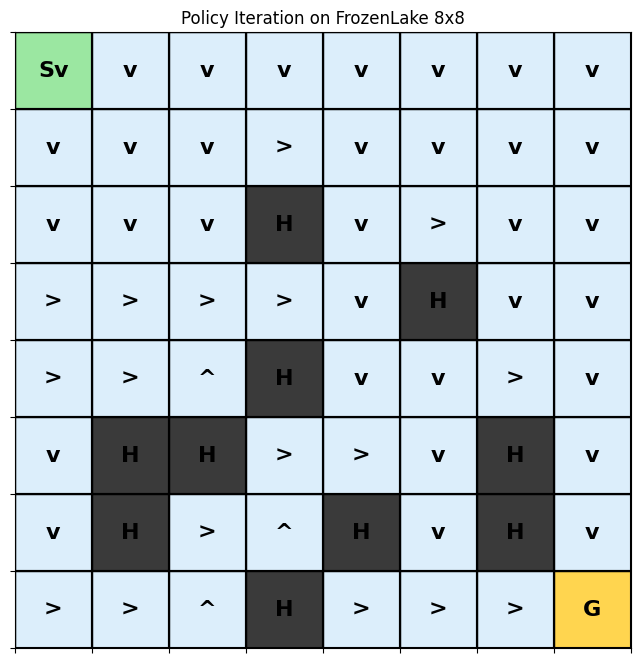

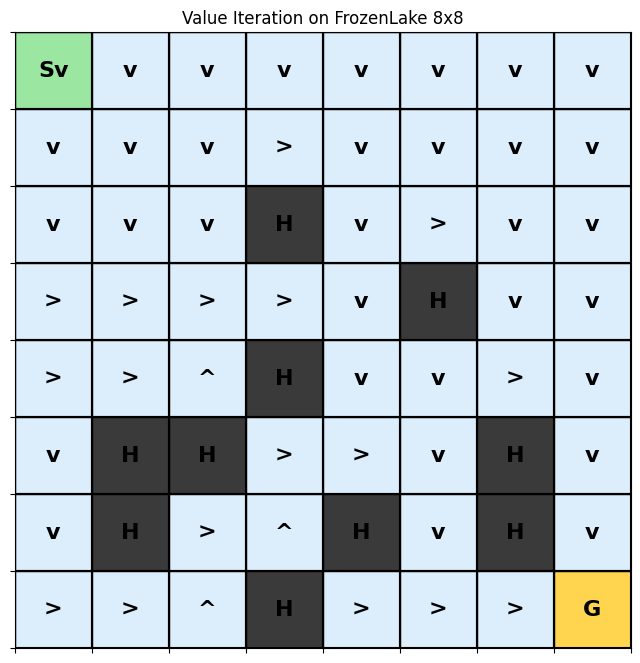

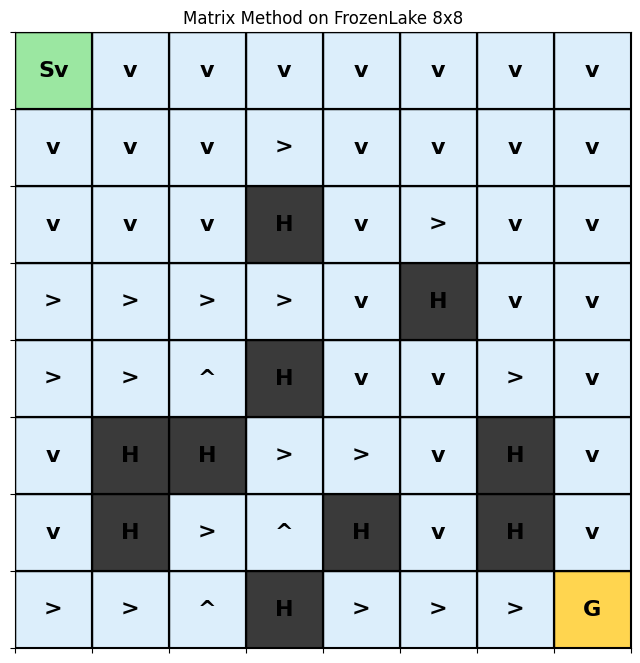

In [71]:
if __name__ == "__main__":
    main()